# Fig3_attention.ipynb

## Introduction
This notebook processes species attention scores in relation to multiple environmental factors. It includes:
1. Calculating overall attention scores.
2. Sorting and visualizing the environmental factor weights.
3. Investigating forest vs non-forest species distinctions.
4. Assessing relationships between attention scores and average elevation.

In [1]:
# Import necessary libraries and modules.
# The PlotUtlis class, create_folder, mm2inch, and set_mpl_defaults come from the Utils.py script.
# They provide helper functionalities such as figure styling, directory creation, and data manipulation.

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail, reorder_df_attention, get_significance_stars
import pandas as pd
import copy
from matplotlib import font_manager as fm
import h5py
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

# Set default plotting parameters (e.g., fonts, axes, etc.)
set_mpl_defaults()

### Translate species name to Chinese

In [44]:
def get_chinese_sciname(target_name):
    change_name_path = os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv')
    df_name = pd.read_csv(change_name_path, index_col=None)
    df_target = df_name[df_name['sciname'] == target_name.replace('_', ' ')]
    return df_target['chiname'].values[0]

In [2]:
# Define run_id and exp_id for referencing the appropriate directories and configurations.
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

In [3]:
# Instantiate PlotUtlis with the given run_id and exp_id.
# This object offers various methods for data loading and path management.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [4]:
# Create output folder paths for storing attention-related plots.
create_folder(PU.plot_path_attention)

### Calculate attention score of each species 

In [ ]:
# Create a DataFrame of attention scores for each species, using PlotUtlis method.
# This averages the attention across all relevant dates. The method internally handles reading the data from h5 files.

df_attention = PU.create_attention_df()
df_attention.to_csv(PU.df_attention_path)

### Sort the attention weights for each environmental factor

In [32]:
# Reads the attention DataFrame from a saved CSV file. Then sums across species for each factor.
# Sort factors by total attention.

df_attention = pd.read_csv(PU.df_attention_path, index_col = 0)
df_attention_sumsort = df_attention.sum().sort_values()
df_attention_sumsort.index = convert_to_env_list_detail(df_attention_sumsort.index)
df_attention_sumsort

Cloud area fraction    103.186466
EVI                    104.580647
LandcoverPC2           104.614852
Shortwave radiation    105.955654
Precipitation          107.465643
LandcoverPC3           109.128954
Relative humidity      112.210294
Temperature            114.100038
LandcoverPC1           120.320070
LandcoverPC4           134.536889
Wind speed             139.900493
dtype: float64

### BAR PLOT

In [65]:
# Reorder the attention DataFrame so it can be plotted in a stacked bar chart.
df_attention_order = reorder_df_attention(df_attention)
# species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
species_list_exclude = []
df_attention_order = df_attention_order[~df_attention_order.index.isin([sp.replace('_', ' ') for sp in species_list_exclude])]

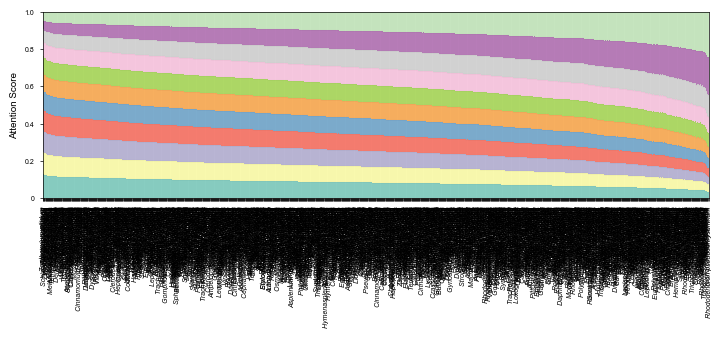

In [8]:
# Create a custom color map for the stacked bar plot.
# Plot stacked bars to visualize the contribution of each environmental factor per species.

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 75), 
                       gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.35, 'top': 0.98})

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

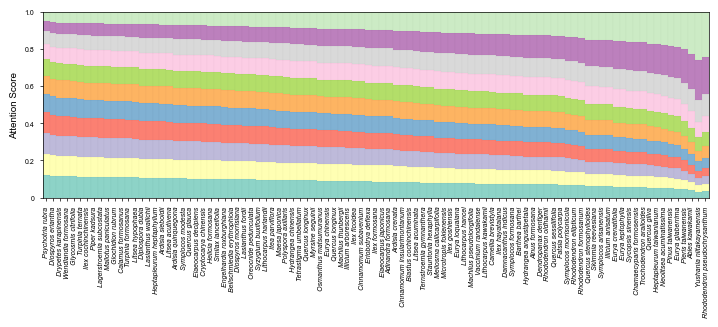

In [68]:
# 20260511 ADD
# plot with less species
# these are TREES
species_list_tree = ['Debregeasia_orientalis', 'Neolitsea_hiiranensis', 'Capparis_micracantha', 'Berberis_mingetsensis', 'Radermachera_sinica', 'Cinnamomum_osmophloeum', 'Cleyera_japonica_var._taipinensis', 'Acer_serrulatum', 'Vaccinium_randaiense', 'Acer_albopurpurascens', 'Polyspora_axillaris', 'Enkianthus_perulatus', 'Machilus_zuihoensis_var._mushaensis', 'Turpinia_formosana', 'Sarcopyramis_napalensis_var._delicata', 'Lithocarpus_harlandii', 'Distyliopsis_dunnii', 'Rubus_formosensis', 'Terminalia_catappa', 'Derris_trifoliata', 'Vernicia_montana', 'Pittosporum_daphniphylloides', 'Trachelospermum_formosanum', 'Macaranga_tanarius', 'Quercus_pachyloma', 'Hydrangea_longifolia', 'Champereia_manillana', 'Dodonaea_viscosa', 'Aeschynanthus_acuminatus', 'Salix_fulvopubescens_var._doii', 'Vernicia_fordii', 'Bombax_ceiba', 'Grewia_rhombifolia', 'Berchemia_lineata', 'Croton_cascarilloides', 'Calocedrus_macrolepis_var._formosana', 'Euonymus_laxiflorus', 'Lepisorus_pseudoussuriensis', 'Actinidia_callosa_var._discolor', 'Crateva_adansonii_subsp._formosensis', 'Vaccinium_kengii', 'Diospyros_oldhamii', 'Castanopsis_eyrei', 'Heptapleurum_heptaphyllum', 'Neolitsea_acuminatissima', 'Ficus_erecta_var._beecheyana', 'Ventilago_leiocarpa', 'Syzygium_densinervium', 'Drypetes_karapinensis', 'Randia_sinensis', 'Lantana_camara', 'Taiwania_cryptomerioides', 'Elaeocarpus_decipiens', 'Ficus_variegata_var._variegata', 'Cayratia_japonica', 'Lagerstroemia_subcostata', 'Ardisia_crenata', 'Triadica_cochinchinensis', 'Kadsura_japonica', 'Albizia_julibrissin', 'Symplocos_koshunensis', 'Nageia_nagi', 'Bretschneidera_sinensis', 'Margaritaria_indica', 'Smilax_bracteata_var._verruculosa', 'Microtropis_japonica', 'Schisandra_arisanensis', 'Euonymus_pallidifolia', 'Oreocnide_pedunculata', 'Ormosia_hengchuniana', 'Aristolochia_kaempferi', 'Osmanthus_matsumuranus', 'Osmanthus_lanceolatus', 'Premna_octonervia', 'Palaquium_formosanum', 'Cinnamomum_insularimontanum', 'Celastrus_kusanoi', 'Syzygium_jambos', 'Hibiscus_syriacus', 'Symplocos_formosana', 'Myrica_adenophora', 'Ficus_subpisocarpa', 'Rubus_kawakamii', 'Camphora_officinarum', 'Actinidia_setosa', 'Zanthoxylum_scandens', 'Lonicera_acuminata', 'Machilus_japonica_var._kusanoi', 'Manihot_esculenta', 'Tetrastigma_bioritsense', 'Ilex_crenata', 'Ilex_tugitakayamensis', 'Styrax_suberifolia', 'Phyllanthus_reticulatus', 'Pistacia_chinensis', 'Cryptomeria_japonica', 'Camellia_oleifera', 'Ardisia_cornudentata_subsp._cornudentata', 'Bridelia_tomentosa', 'Litsea_perrottetii', 'Dimocarpus_longan', 'Mallotus_paniculatus', 'Abies_kawakamii', 'Aucuba_japonica', 'Cleyera_japonica_var._longicarpa', 'Symplocos_caudata', 'Cinnamomum_reticulatum', 'Drypetes_littoralis', 'Stachyurus_himalaicus', 'Juniperus_formosana_var._formosana', 'Cassia_grandis', 'Lasianthus_japonicus', 'Quercus_hypophaea', 'Adinandra_formosana', 'Quercus_gilva', 'Osmanthus_heterophyllus', 'Quercus_longinux', 'Zanthoxylum_pistaciiflorum', 'Callicarpa_tikusikensis', 'Stauntonia_hexaphylla', 'Callicarpa_longissima', 'Heptapleurum_ellipticum', 'Aucuba_chinensis_var._chinensis', 'Parthenocissus_tricuspidata', 'Mallotus_paniculatus_var._formosanus', 'Carpinus_rankanensis', 'Scolopia_oldhamii', 'Broussonetia_papyrifera', 'Lasianthus_bunzanensis', 'Strychnos_cathayensis', 'Cinnamomum_macrostemon', 'Viburnum_plicatum_var._formosanum', 'Bridelia_balansae', 'Rubus_yuliensis', 'Pittosporum_tobira', 'Rhododendron_tashiroi', 'Diospyros_morrisiana', 'Pittosporum_illicioides_var._angustifolium', 'Castanopsis_fargesii', 'Sinopanax_formosanus', 'Actinidia_latifolia', 'Viburnum_urceolatum', 'Melia_azedarach', 'Lindera_aggregata_var._aggregata', 'Leea_philippinensis', 'Fatsia_polycarpa', 'Sambucus_chinensis', 'Phyllanthus_oligospermus', 'Symplocos_congesta_var._theifolia', 'Guettarda_speciosa', 'Tsuga_chinensis_var._formosana', 'Archidendron_lucidum', 'Camellia_japonica', 'Eurycorymbus_cavaleriei', 'Aglaia_elliptifolia', 'Rhododendron_kawakamii', 'Prinsepia_scandens', 'Cinchona_ledgeriana', 'Diospyros_rhombifolia', 'Callicarpa_randaiensis', 'Castanopsis_indica', 'Rhaphiolepis_indica_var._tashiroi', 'Mallotus_japonicus', 'Adinandra_lasiostyla', 'Carpinus_hebestroma', 'Eustigma_oblongifolium', 'Antidesma_japonicum_var._densiflorum', 'Melastoma_candidum', 'Cleyera_japonica_var._japonica', 'Lasianthus_wallichii', 'Aralia_bipinnata', 'Malus_doumeri', 'Euchresta_formosana', 'Aphananthe_aspera', 'Ficus_ampelos', 'Murraya_omphalocarpa', 'Medinilla_formosana', 'Rhododendron_pseudochrysanthum', 'Heptapleurum_taiwanianum', 'Randia_cochinchinensis', 'Photinia_niitakayamensis', 'Litsea_akoensis_var._sasakii', 'Rhododendron_breviperulatum', 'Euonymus_oxyphyllus', 'Koelreuteria_henryi', 'Homalium_cochinchinensis', 'Lithocarpus_glaber', 'Rhamnus_formosana', 'Rhododendron_formosanum', 'Viburnum_erosum', 'Ehretia_resinosa', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Rhamnus_nakaharae', 'Pometia_pinnata', 'Stauntonia_obovata', 'Severinia_buxifolia', 'Rhododendron_ovatum_var._lamprophyllum', 'Neolitsea_parvigemma', 'Ficus_esquiroliana', 'Calophyllum_inophyllum', 'Decaspermum_gracilentum', 'Castanopsis_cuspidata_var._carlesii', 'Lithocarpus_kawakamii', 'Symplocos_arisanensis', 'Capparis_floribunda', 'Myrica_rubra', 'Ilex_bioritsensis', 'Vaccinium_wrightii_var._formosanum', 'Ardisia_japonica', 'Machilus_zuihoensis_var._zuihoensis', 'Zanthoxylum_nitidum', 'Tetradium_glabrifolium', 'Syzygium_paucivenium', 'Sycopsis_sinensis', 'Ilex_cochinchinensis', 'Euscaphis_japonica', 'Clerodendrum_canescens', 'Syzygium_buxifolium', 'Boehmeria_densiflora', 'Quercus_repandifolia', 'Premna_microphylla', 'Ficus_ruficaulis_var._antaoensis', 'Illicium_tashiroi', 'Helicia_formosana', 'Viburnum_luzonicum', 'Quercus_sessilifolia', 'Pueraria_montana', 'Lygodium_japonicum', 'Berberis_aristatoserrulata', 'Picrasma_quassioides', 'Photinia_serratifolia_var._ardisiifolia', 'Neolitsea_sericea_var._sericea', 'Astronia_formosana', 'Aralia_finlaysoniana', 'Akebia_longeracemosa', 'Sorbus_randaiensis', 'Berchemia_formosana', 'Neolitsea_buisanensis_fo._buisanensis', 'Arenga_engleri', 'Antidesma_japonicum_var._acutisepalum', 'Melicope_pteleifolia', 'Distylium_gracile', 'Acer_caudatifolium', 'Cunninghamia_lanceolata', 'Photinia_serratifolia_var._serratifolia', 'Elaeagnus_grandifolia', 'Symplocos_nokoensis', 'Ficus_pumila_var._pumila', 'Schizophragma_fauriei', 'Symplocos_cochinchinensis_var._cochinchinensis', 'Euonymus_spraguei', 'Viburnum_taitoense', 'Rhododendron_chilanshanense', 'Quercus_variabilis', 'Pterocarpus_indicus', 'Acer_morrisonense', 'Ilex_lonicerifolia_var._matsudae', 'Itea_parviflora', 'Sabia_swinhoei', 'Blastus_cochinchinensis', 'Alsophila_podophylla', 'Mahonia_japonica', 'Heliotropium_formosanum', 'Rhodomyrtus_tomentosa', 'Cleyera_japonica_var._morii', 'Skimmia_reevesiana', 'Viburnum_formosanum', 'Viburnum_foetidum_var._rectangulatum', 'Phoebe_formosana', 'Heptapleurum_arboricola', 'Leucaena_leucocephala', 'Ficus_fistulosa_fo._benguetensis', 'Embelia_rudis', 'Turpinia_ternata', 'Strobilanthes_longespicatus', 'Paederia_foetida', 'Salix_warburgii', 'Symplocos_trichoclada', 'Acalypha_suirenbiensis', 'Pisonia_umbellifera', 'Camellia_sasanqua', 'Vitex_quinata', 'Acacia_caesia', 'Thespesia_populnea', 'Pourthiaea_beauverdiana_var._notabilis', 'Symplocos_stellaris', 'Erycibe_henryi', 'Prunus_taiwaniana', 'Vaccinium_bracteatum', 'Anneslea_fragrans_var._lanceolata', 'Neolitsea_aciculata_var._variabillima', 'Psidium_guajava', 'Actinidia_rufa', 'Bredia_oldhamii', 'Zanthoxylum_armatum', 'Cornus_kousa', 'Euonymus_carnosus', 'Rhododendron_hyperythrum', 'Viburnum_propinquum', 'Ilex_suzukii', 'Styrax_matsumurae', 'Callicarpa_kochiana', 'Eriobotrya_deflexa', 'Tetrastigma_formosanum', 'Sassafras_randaiense', 'Cornus_macrophylla', 'Tetrastigma_umbellatum', 'Diospyros_japonica', 'Wendlandia_uvariifolia', 'Picea_morrisonicola', 'Urceola_rosea', 'Meliosma_rigida', 'Neolitsea_konishii', 'Deutzia_pulchra', 'Rhamnus_crenata', 'Glochidion_philippicum', 'Ficus_septica', 'Strobilanthes_formosanus', 'Prunus_zippeliana', 'Castanopsis_formosana', 'Vitex_negundo', 'Lithocarpus_corneus', 'Symplocos_modesta', 'Smilax_bracteata_var._bracteata', 'Lithocarpus_amygdalifolius', 'Eurya_strigillosa', 'Deutzia_taiwanensis', 'Millettia_pachycarpa', 'Callicarpa_pilosissima', 'Nageia_fleuryi', 'Lithocarpus_nantoensis', 'Ilex_pubescens', 'Piper_kadsura', 'Vaccinium_merrillianum', 'Gymnema_sylvestre', 'Osmanthus_enervius', 'Castanopsis_fabri', 'Garcinia_multiflora', 'Flueggea_suffruticosa', 'Ventilago_elegans', 'Symplocos_setchuensis', 'Buxus_microphylla_subsp._sinica', 'Aglaia_formosana', 'Vaccinium_japonicum_var._lasiostemon', 'Illicium_arborescens', 'Machilus_obovatifolia', 'Berberis_kawakamii', 'Callicarpa_remotiserrulata', 'Engelhardia_roxburghiana', 'Callicarpa_formosana_var._glabrata', 'Ficus_microcarpa_var._crassifolia', 'Clematis_tashiroi', 'Cordia_aspera', 'Tarenna_gracilipes', 'Meliosma_squamulata', 'Trachelospermum_gracilipes', 'Zelkova_serrata', 'Lasianthus_curtisii', 'Rhaphiolepis_indica_var._hiiranensis', 'Glochidion_zeylanicum_var._zeylanicum', 'Lasianthus_appressihirtus_var._appressihirtus', 'Calamus_beccarii', 'Alsophila_loheri', 'Lithocarpus_lepidocarpus', 'Quercus_globosa', 'Styrax_formosana', 'Diplospora_dubia', 'Sageretia_thea', 'Lasianthus_appressihirtus_var._maximus', 'Symplocos_grandis', 'Vaccinium_emarginatum', 'Sinoadina_racemosa', 'Machilus_pseudolongifolia', 'Toddalia_asiatica', 'Zanthoxylum_schinifolium', 'Rhus_succedanea_var._succedanea', 'Breynia_officinalis_var._officinalis', 'Ficus_punctata', 'Camphora_kanahirae', 'Rhamnus_parvifolia', 'Berberis_morrisonensis', 'Reevesia_formosana', 'Cryptocarya_concinna', 'Ficus_tinctoria', 'Alnus_formosana', 'Machilus_thunbergii', 'Berchemia_racemosa_var._magna', 'Calamus_formosanus', 'Melicope_semecarpifolia', 'Litsea_cubeba', 'Quercus_glauca', 'Dysoxylum_hongkongense', 'Boehmeria_nivea_var._tenacissima', 'Ficus_microcarpa_var._microcarpa', 'Diospyros_philippensis', 'Sphaeropteris_lepifera', 'Lindera_communis', 'Viburnum_integrifolium', 'Viburnum_odoratissimum', 'Malus_hupehensis', 'Sageretia_randaiensis', 'Magnolia_compressa_var._formosana', 'Erythrina_variegata', 'Pittosporum_pentandrum', 'Pourthiaea_villosa_var._parvifolia', 'Eurya_loquaiana', 'Beilschmiedia_erythrophloia', 'Quercus_salicina', 'Camellia_furfuracea', 'Schima_superba_var._kankaoensis', 'Ulmus_parvifolia', 'Fraxinus_insularis', 'Clematis_henryi_var._morii', 'Lasianthus_biflorus', 'Rhamnus_pilushanensis', 'Litsea_acutivena', 'Euonymus_tashiroi', 'Schoepfia_jasminodora', 'Ilex_uraiensis', 'Quercus_tatakaensis', 'Litsea_morrisonensis', 'Smilax_china', 'Jasminum_sinense', 'Medinilla_taiwaniana', 'Camellia_transarisanensis', 'Ehretia_acuminata', 'Ulmus_uyematsui', 'Lithocarpus_synbalanos', 'Ficus_caulocarpa', 'Castanopsis_kawakamii', 'Alsophila_spinulosa', 'Paulownia_fortunei', 'Gaultheria_cumingiana', 'Ilex_sugerokii_var._brevipedunculata', 'Styrax_hayataianus', 'Bauhinia_variegata', 'Prunus_transarisanensis_var._takasagomontana', 'Symplocos_chinensis', 'Syzygium_kusukusense', 'Buxus_liukiuensis', 'Pouzolzia_elegans', 'Celtis_sinensis', 'Citrus_reticulata_var._depressa', 'Elaeocarpus_japonicus', 'Pentapanax_castanopsidicola', 'Phellodendron_amurense_var._wilsonii', 'Trichodesma_calycosum', 'Cinnamomum_brevipedunculatum', 'Spiraea_thunbergii', 'Lasianthus_fordii', 'Chamaecyparis_obtusa_var._formosana', 'Neolitsea_aciculata_var._aciculata', 'Clematis_uncinata_var._uncinata', 'Rhododendron_rubropunctatum', 'Neonauclea_reticulata', 'Miscanthus_floridulus', 'Ilex_ficoidea', 'Symplocos_heishanensis', 'Prunus_obtusata', 'Camphora_micrantha', 'Anodendron_affine', 'Celtis_biondii', 'Pandanus_odorifer', 'Eurya_acuminata', 'Nekemias_cantoniensis', 'Artocarpus_treculianus', 'Hydrangea_angustipetala', 'Pileostegia_viburnoides', 'Sarcandra_glabra', 'Brucea_javanica', 'Glochidion_zeylanicum_var._lanceolatum', 'Hydrangea_anomala', 'Callicarpa_hypoleucophylla', 'Citrus_maxima', 'Damnacanthus_angustifolius', 'Ampelopsis_brevipedunculata_var._hancei', 'Leea_guineensis', 'Fissistigma_glaucescens', 'Xylosma_congesta', 'Liquidambar_formosana', 'Camellia_caudata', 'Pittosporum_illicioides_var._illicioides', 'Quercus_longinux_var._kuoi', 'Maytenus_diversifolia', 'Ilex_arisanensis', 'Microlepia_×_bipinnata', 'Magnolia_kachirachirai', 'Photinia_lucida', 'Eurya_hayatae', 'Symplocos_congesta_var._congesta', 'Celastrus_hindsii', 'Ardisia_sieboldii', 'Chrinephrium_insulare', 'Firmiana_simplex', 'Litsea_acuminata', 'Rhus_sylvestris', 'Smilax_planipedunculata', 'Premna_serratifolia', 'Cephalotaxus_wilsoniana', 'Prunus_matuurae', 'Hydrangea_paniculata', 'Ilex_maximowicziana', 'Juglans_cathayensis', 'Amentotaxus_formosana', 'Symplocos_sonoharae_var._sonoharae', 'Tetradium_ruticarpum', 'Castanopsis_cuspidata_fo._sessilis', 'Magnolia_compressa_var._compressa', 'Ilex_goshiensis', 'Strobilanthes_flexicaulis', 'Celtis_nervosa', 'Symplocos_theophrastifolia', 'Cunninghamia_konishii', 'Prunus_spinulosa', 'Eurya_crenatifolia', 'Cinnamomum_subavenium', 'Stephanandra_incisa', 'Capparis_sikkimensis_subsp._formosana', 'Camellia_transnokoensis', 'Epipremnum_pinnatum', 'Derris_laxiflora', 'Clausena_excavata', 'Daphne_arisanensis', 'Pinus_armandii_var._mastersiana', 'Antidesma_hiiranense', 'Citrus_×_taiwanica', 'Ehretia_longiflora', 'Ilex_yunnanensis', 'Callicarpa_dichotoma', 'Glycosmis_citrifolia', 'Ilex_formosana', 'Camellia_formosensis', 'Citrus_tachibana', 'Smilax_corbularia', 'Skimmia_arisanensis', 'Casearia_membranacea', 'Osmanthus_marginatus', 'Zanthoxylum_avicennae', 'Celastrus_punctatus', 'Dendrocalamus_latiflorus', 'Alniphyllum_pterospermum', 'Podocarpus_fasciculus', 'Blumea_lacera', 'Gaultheria_itoana', 'Amischotolype_hispida', 'Mucuna_macrocarpa', 'Photinia_serratifolia_var._lasiopetala', 'Sloanea_formosana', 'Eurya_chinensis', 'Maesa_japonica', 'Murraya_euchrestifolia', 'Pongamia_pinnata', 'Rhododendron_rubropilosum_var._rubropilosum', 'Podocarpus_macrophyllus_var._maki', 'Acalypha_matudae', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Melanolepis_multiglandulosa', 'Machilus_konishii', 'Viburnum_parvifolium', 'Myrsine_seguinii', 'Salix_fulvopubescens_var._fulvopubescens', 'Hymenophyllum_fujisanense', 'Quercus_championii', 'Falcataria_falcata', 'Trema_orientalis', 'Abelia_chinensis_var._ionandra', 'Helicia_rengetiensis', 'Mallotus_repandus', 'Camellia_nokoensis', 'Callerya_nitida_var._nitida', 'Barthea_barthei', 'Mahonia_oiwakensis', 'Callicarpa_remotiflora', 'Tarenna_zeylanica', 'Lithocarpus_dodonaeifolius', 'Dalbergia_benthamii', 'Syzygium_euphlebium', 'Hydrangea_chinensis', 'Celtis_tetrandra', 'Mussaenda_pubescens', 'Symplocos_migoi', 'Psychotria_serpens', 'Strobilanthes_cusia', 'Aralia_decaisneana', 'Symplocos_glauca', 'Pyrenaria_shinkoensis', 'Hibiscus_taiwanensis', 'Fissistigma_oldhamii', 'Distylium_racemosum', 'Pueraria_montana_var._lobata', 'Castanopsis_uraiana', 'Glochidion_rubrum', 'Rhododendron_ovatum_var._ovatum', 'Platycarya_strobilacea', 'Prunus_buergeriana', 'Alangium_chinense', 'Machilus_philippinensis', 'Marsdenia_formosana', 'Bredia_gibba', 'Pilea_aquarum_subsp._brevicornuta', 'Ficus_formosana_fo._formosana', 'Rubus_mesogaeus', 'Wikstroemia_lanceolata', 'Ilex_lonicerifolia_var._lonicerifolia', 'Hibiscus_tiliaceus', 'Tetrapanax_papyriferus', 'Lasianthus_cyanocarpus', 'Hiptage_benghalensis', 'Piper_sintenense', 'Quercus_tarokoensis', 'Eurya_nitida_var._nitida', 'Embelia_lenticellata', 'Barringtonia_asiatica', 'Rhamnus_chingshuiensis_var._tashanensis', 'Lasianthus_chinensis', 'Litsea_coreana', 'Phanera_championii', 'Eurya_leptophylla', 'Maclura_cochinchinensis', 'Diospyros_eriantha', 'Elaeagnus_glabra', 'Ficus_virgata', 'Claoxylon_brachyandrum', 'Deutzia_cordatula', 'Wikstroemia_indica', 'Triadica_sebifera', 'Ficus_nervosa', 'Ligustrum_liukiuense', 'Lindera_akoensis', 'Meliosma_callicarpifolia', 'Daphniphyllum_membranaceum', 'Lithocarpus_shinsuiensis', 'Quercus_spinosa', 'Embelia_laeta_var._papilligera', 'Podocarpus_nakaii', 'Meliosma_rhoifolia', 'Christella_parasitica', 'Strobilanthes_rankanensis', 'Prunus_transarisanensis', 'Eurya_glaberrima', 'Helicia_cochinchinensis', 'Saurauia_oldhamii', 'Lasianthus_obliquinervis_var._obliquinervis', 'Hydrangea_aspera', 'Symplocos_shilanensis', 'Viburnum_arboricolum', 'Prunus_phaeosticta_var._ilicifolia', 'Rubus_pyrifolius', 'Derris_elliptica', 'Ailanthus_altissima_var._tanakai', 'Glochidion_acuminatum', 'Hernandia_nymphiifolia', 'Actinidia_arguta', 'Fraxinus_griffithii', 'Spiraea_prunifolia', 'Dendrocnide_meyeniana', 'Eurya_gnaphalocarpa', 'Camellia_assamica', 'Premna_odorata', 'Musa_basjoo_var._formosana', 'Lindera_megaphylla', 'Broussonetia_monoica', 'Litsea_lii_var._lii', 'Itea_oldhamii', 'Coriaria_japonica_subsp._intermedia', 'Fagus_hayatae', 'Symplocos_sasakii', 'Ligustrum_sinense', 'Bischofia_javanica', 'Ternstroemia_gymnanthera', 'Callicarpa_formosana_var._longifolia', 'Ardisia_cornudentata_subsp._morrisonensis_var._stenosepala', 'Idesia_polycarpa', 'Gardenia_jasminoides', 'Cornus_controversa', 'Ilex_micrococca', 'Rhus_ambigua', 'Podocarpus_macrophyllus_var._macrophyllus', 'Embelia_laeta', 'Camellia_brevistyla', 'Litsea_hypophaea', 'Schima_superba_var._superba', 'Anodendron_benthamianum', 'Wendlandia_formosana', 'Rhaphiolepis_indica_var._umbellata', 'Wisteriopsis_reticulata_var._reticulata', 'Yushania_niitakayamensis', 'Trochodendron_aralioides', 'Ficus_irisana', 'Ficus_benjamina', 'Lyonia_ovalifolia_var._ovalifolia', 'Morus_australis', 'Mallotus_philippensis', 'Sabia_transarisanensis', 'Castanopsis_kusanoi', 'Acer_palmatum_var._pubescens', 'Lindera_erythrocarpa', 'Ormosia_formosana', 'Elaeagnus_formosana', 'Rhododendron_noriakianum', 'Lasianthus_microstachys', 'Freycinetia_formosana', 'Quercus_stenophylloides', 'Microtropis_fokienensis', 'Damnacanthus_indicus', 'Litchi_chinensis', 'Annona_squamosa', 'Acacia_confusa', 'Camellia_salicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Maesa_perlaria_var._formosana', 'Cinchona_succirubra', 'Beilschmiedia_tsangii', 'Litsea_akoensis_var._akoensis', 'Pieris_taiwanensis', 'Zanthoxylum_ailanthoides', 'Prunus_campanulata', 'Carpinus_kawakamii', 'Osmanthus_kaoi', 'Brugmansia_suaveolens', 'Wikstroemia_taiwanensis', 'Clerodendrum_trichotomum', 'Litsea_elongata_var._mushaensis', 'Rubus_swinhoei_var._swinhoei', 'Cotoneaster_konishii', 'Illicium_anisatum', 'Ribes_formosanum', 'Phoenix_hanceana', 'Dendropanax_dentiger', 'Smilax_lanceifolia', 'Allophylus_timorensis', 'Lasianthus_microphyllus', 'Lithocarpus_konishii', 'Rhododendron_oldhamii', 'Hydrangea_integrifolia', 'Sapindus_mukorossi', 'Rhododendron_ellipticum', 'Ardisia_virens', 'Buchanania_arborescens', 'Psychotria_rubra', 'Rhododendron_mariesii', 'Malaisia_scandens', 'Daphne_kiusiana_var._atrocaulis', 'Lindera_glauca', 'Cymbidium_lancifolium_var._aspidistrifolium', 'Ficus_fistulosa_fo._fistulosa', 'Litsea_rotundifolia_var._oblongifolia', 'Ehretia_dicksonii', 'Clematis_grata', 'Lithocarpus_hancei', 'Deparia_jiulungensis', 'Ilex_hayataiana', 'Hedera_rhombea_var._formosana', 'Helwingia_japonica_subsp._taiwaniana', 'Boehmeria_wattersii', 'Symplocos_wikstroemiifolia', 'Liodendron_formosanum', 'Neolitsea_daibuensis', 'Syzygium_formosanum', 'Cryptocarya_chinensis', 'Randia_canthioides', 'Kleinhovia_hospita', 'Ficus_sarmentosa_var._nipponica', 'Bredia_hirsuta_var._scandens', 'Pinus_taiwanensis', 'Viburnum_sympodiale', 'Ardisia_quinquegona', 'Pinus_morrisonicola', 'Pisonia_aculeata', 'Ilex_rotunda', 'Juniperus_squamata', 'Viburnum_betulifolium', 'Antidesma_pentandrum_var._barbatum', 'Uncaria_hirsuta', 'Rhus_javanica_var._roxburghiana', 'Murraya_paniculata', 'Symplocos_acuminata', 'Perrottetia_arisanensis', 'Taxus_sumatrana', 'Grewia_biloba', 'Ilex_asprella', 'Symplocos_eriostroma', 'Akebia_trifoliata_subsp._australis', 'Symplocos_konishii', 'Callicarpa_formosana_var._formosana', 'Litsea_lii_var._nunkao-tahangensis', 'Ligustrum_pricei', 'Ligustrum_morrisonense', 'Clerodendrum_cyrtophyllum', 'Chamaecyparis_formosensis', 'Lasianthus_formosensis', 'Vaccinium_wrightii_var._wrightii', 'Gleditsia_rolfei', 'Cinnamomum_austrosinense', 'Elaeagnus_thunbergii', 'Ilex_pedunculosa', 'Planchonella_obovata', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Capparis_acutifolia', 'Smilax_menispermoidea', 'Timonius_arboreus', 'Mangifera_indica', 'Symplocos_morrisonicola', 'Pseudotsuga_wilsoniana']

# 20260508 ADD
# Trees with occurrence records more than 80% percentile among all species
species_list_prediect_percentile80 = ['Abies_kawakamii', 'Adinandra_formosana', 'Alnus_formosana', 'Arachniodes_amabilis_var._fimbriata', 'Ardisia_cornudentata_subsp._cornudentata', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Ardisia_crenata', 'Ardisia_quinquegona', 'Ardisia_sieboldii', 'Barthea_barthei', 'Beilschmiedia_erythrophloia', 'Blastus_cochinchinensis', 'Calamus_formosanus', 'Camellia_brevistyla', 'Castanopsis_cuspidata_var._carlesii', 'Chamaecyparis_formosensis', 'Cinnamomum_insularimontanum', 'Cinnamomum_subavenium', 'Cleyera_japonica_var._japonica', 'Cryptocarya_chinensis', 'Damnacanthus_indicus', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Dendropanax_dentiger', 'Diospyros_eriantha', 'Diospyros_morrisiana', 'Diplazium_dilatatum', 'Diplospora_dubia', 'Dryopteris_formosana', 'Drypetes_karapinensis', 'Elaeocarpus_decipiens', 'Elaeocarpus_japonicus', 'Elatostema_lineolatum_var._majus', 'Engelhardia_roxburghiana', 'Eriobotrya_deflexa', 'Eurya_chinensis', 'Eurya_crenatifolia', 'Eurya_glaberrima', 'Eurya_leptophylla', 'Eurya_loquaiana', 'Fatsia_polycarpa', 'Ficus_erecta_var._beecheyana', 'Ficus_fistulosa_fo._fistulosa', 'Glochidion_rubrum', 'Glycosmis_citrifolia', 'Helicia_formosana', 'Heptapleurum_heptaphyllum', 'Heptapleurum_taiwanianum', 'Hydrangea_angustipetala', 'Hydrangea_chinensis', 'Ilex_cochinchinensis', 'Ilex_ficoidea', 'Ilex_formosana', 'Ilex_goshiensis', 'Ilex_hayataiana', 'Illicium_anisatum', 'Illicium_arborescens', 'Itea_parviflora', 'Lagerstroemia_subcostata', 'Lasianthus_fordii', 'Lasianthus_wallichii', 'Lemmaphyllum_microphyllum', 'Lithocarpus_hancei', 'Lithocarpus_harlandii', 'Lithocarpus_kawakamii', 'Litsea_acuminata', 'Litsea_acutivena', 'Litsea_elongata_var._mushaensis', 'Litsea_hypophaea', 'Lyonia_ovalifolia_var._ovalifolia', 'Machilus_japonica_var._kusanoi', 'Machilus_pseudolongifolia', 'Machilus_thunbergii', 'Machilus_zuihoensis_var._mushaensis', 'Machilus_zuihoensis_var._zuihoensis', 'Maesa_japonica', 'Maesa_perlaria_var._formosana', 'Magnolia_compressa_var._compressa', 'Mallotus_paniculatus', 'Meliosma_callicarpifolia', 'Microtropis_fokienensis', 'Monachosorum_henryi', 'Myrsine_seguinii', 'Neolitsea_aciculata_var._variabillima', 'Neolitsea_acuminatissima', 'Oreocnide_pedunculata', 'Osmanthus_matsumuranus', 'Pieris_taiwanensis', 'Pinus_taiwanensis', 'Piper_kadsura', 'Pittosporum_illicioides_var._illicioides', 'Plagiogyria_euphlebia', 'Polyspora_axillaris', 'Pothos_chinensis', 'Prunus_phaeosticta_var._phaeosticta', 'Psychotria_rubra', 'Quercus_gilva', 'Quercus_glauca', 'Quercus_longinux', 'Quercus_sessilifolia', 'Quercus_stenophylloides', 'Rhododendron_ellipticum', 'Rhododendron_formosanum', 'Rhododendron_oldhamii', 'Rhododendron_pseudochrysanthum', 'Rhododendron_rubropilosum_var._rubropilosum', 'Schima_superba_var._superba', 'Skimmia_reevesiana', 'Smilax_lanceifolia', 'Stauntonia_hexaphylla', 'Sycopsis_sinensis', 'Symplocos_arisanensis', 'Symplocos_formosana', 'Symplocos_modesta', 'Symplocos_morrisonicola', 'Syzygium_buxifolium', 'Ternstroemia_gymnanthera', 'Tetrastigma_umbellatum', 'Tricholepidium_buergerianum', 'Trochodendron_aralioides', 'Tsuga_chinensis_var._formosana', 'Turpinia_formosana', 'Turpinia_ternata', 'Vaccinium_randaiense', 'Viburnum_foetidum_var._rectangulatum', 'Wendlandia_formosana', 'Yushania_niitakayamensis']
species_list_less_than_percentile80 = set(PU.species_list_predict) - set(species_list_prediect_percentile80)
species_list_grass = set(PU.species_list_predict) - set(species_list_tree)
species_list_exclude = list(set(species_list_less_than_percentile80) | set(species_list_grass))

# Reorder the attention DataFrame so it can be plotted in a stacked bar chart.
df_attention_order = reorder_df_attention(df_attention)
df_attention_order = df_attention_order[df_attention_order.index.isin([sp.replace('_', ' ') for sp in list(set(PU.species_list_predict) - set(species_list_exclude))])]

# Create a custom color map for the stacked bar plot.
# Plot stacked bars to visualize the contribution of each environmental factor per species.

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 75), 
                       gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.35, 'top': 0.98})

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot_less_species.pdf')
# plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

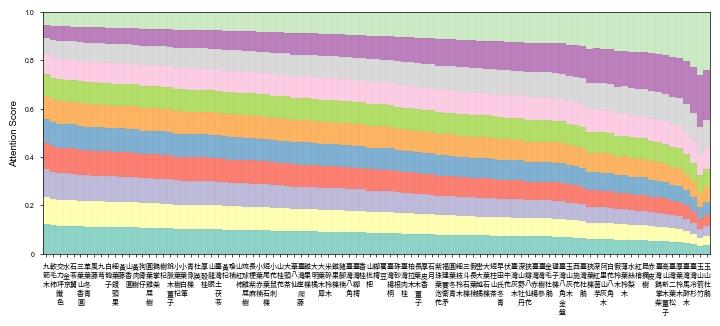

In [69]:
from matplotlib import font_manager as fm

font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 80), constrained_layout = True)

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
chinesename = [get_chinese_sciname(sp.replace(' ', '_')) for sp in df_attention_order.index]
chinesenmae_plot = [sp.replace('', '\n')[1:-1] for sp in chinesename]

ax.set_xticklabels(chinesenmae_plot, ha='center', va='top', fontproperties = font_prop, rotation = 0)
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot_chinese.pdf')
# plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

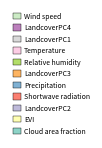

In [81]:
from matplotlib.patches import Patch

# 反轉 legend 顯示順序：最後一個環境因子放到最前面
legend_order = list(df_attention_order.columns)[::-1]

# === 單獨畫 legend ===
legend_handles = [
    Patch(
        facecolor=custom_cmap[name],
        edgecolor="black",
        linewidth=0.3,
        label=name
    )
    for name in legend_order
]

fig_leg, ax_leg = plt.subplots(
    figsize=mm2inch(20, 30),
    constrained_layout=True
)

ax_leg.axis("off")

ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,                 # 12 個項目的話會排成 2 列，可自行改成 4 或 12
    frameon=False,
    prop=font_prop,          # 如果 legend 有中文，保留這行
    handlelength=1.2,
    handleheight=1.0,
    columnspacing=1.2,
    handletextpad=0.4
)

legend_output = os.path.join(
    PU.plot_path_attention,
    "attention_barplot_legend_chinese.pdf"
)

plt.savefig(
    legend_output,
    dpi=500,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

### Forest habitat

In [30]:
# Retrieve habitat designations (forest vs non-forest) for each species in the order of df_attention_order.
habitat = PU.get_species_habitat(df_attention_order)

In [31]:
import pandas as pd
import numpy as np

# 1) Convert the habitat list into a Series aligned with df_attention_order
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# 2) Sum of each habitat — equal to the number of species in that habitat 
#    (since each species contributes one row with total sum = 1)
attn_sum_by_hab = df_attention_order.groupby(hab_s).sum().sort_index()

# 3) Mean of each habitat — equivalent to dividing the summed values by 
#    the number of species in each habitat (same as .mean())
attn_mean_by_hab = df_attention_order.groupby(hab_s).mean().sort_index()

# 4) Proportion within each habitat — normalize each habitat’s total so 
#    that the sum across environmental variables equals 1
#    (row-normalization of the habitat-level sums)
attn_prop_by_hab = attn_sum_by_hab.div(attn_sum_by_hab.sum(axis=1), axis=0)

# 5) Alignment checks (recommended sanity checks)
assert len(habitat) == len(df_attention_order)
assert np.allclose(attn_sum_by_hab.sum(axis=1).values, hab_s.value_counts().sort_index().values)

# 6) Extract the top three most important environmental variables 
#    (by proportion) for each habitat
top3_each_hab = (
    attn_prop_by_hab
      .stack()                                # → Long-format index (Habitat, Env)
      .groupby(level=0)                       # Group by habitat
      .apply(lambda s: s.sort_values(ascending=False).head(3))
)


In [32]:
import pandas as pd
import numpy as np

# Alignment check (optional but recommended)
assert len(habitat) == len(df_attention_order)

# Convert habitat list into a Series aligned with species index
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# Count the number of species in each habitat
n_by_hab = hab_s.value_counts().sort_index()
print(n_by_hab)

# Save to CSV file (optional)
n_by_hab.rename_axis('Habitat').to_frame('n_species').to_csv('n_species_by_habitat.csv')


Habitat
Habitat_DrylandFarming            1
Habitat_Forest                   87
Habitat_ForestEdge               11
Habitat_FreshwaterLakesPools      1
Habitat_MiddleUpperOfStream       5
Habitat_PermanentInlandDeltas     4
Habitat_RockyShoreline            1
Habitat_Shortgrass                5
Habitat_Shrubland                 4
Habitat_Tallgrass                 2
Name: count, dtype: int64


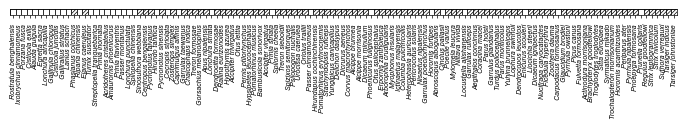

In [33]:
# Create a figure that visually marks forest vs non-forest species using hatching.
# Each rectangle in the figure is hatched or not based on the habitat.

forest_hatch = '/////////'
non_forest_hatch = ''
fig, ax = plt.subplots(figsize = mm2inch(180, 30), gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.93, 'top': 0.98})

for i, h in enumerate(habitat):
    if h == 'Habitat_Forest':
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,      
            facecolor='white', 
            edgecolor='black', 
            hatch=forest_hatch,
            linewidth = 0.5
        )
    else:
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,
            facecolor='white',
            edgecolor='black',
            hatch=non_forest_hatch,
            linewidth = 0.5
        )
    ax.add_patch(rect)

ax.set_xlim(0, len(habitat))
ax.set_ylim(0, 1)
ax.set_xticks(range(len(habitat)))
ax.set_xticks(np.arange(len(df_attention_order.index))+0.5)
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_yticks([])

plot_output = os.path.join(PU.plot_path_attention, 'forest.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Attention score by environmental factors

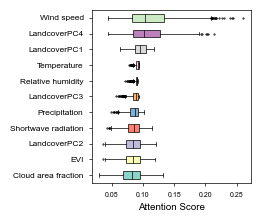

In [66]:
# Draw boxplots for each environmental factor across all species.
# The custom color list is used to distinguish different factors.
fig, ax = plt.subplots(figsize = mm2inch(65, 55), gridspec_kw = {'left': 0.33, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
box = ax.boxplot(df_attention_order.values, vert = False, patch_artist = True, tick_labels = df_attention_order.columns,
                 medianprops = dict(color = 'black'),
                )

for patch, label in zip(box['boxes'], df_attention_order.columns):
    patch.set_facecolor(custom_cmap[label])
    patch.set_edgecolor('black')

ax.set_xlabel("Attention Score")
ax.set_yticklabels(list(df_attention_order.columns), fontsize = 6)

plot_output = os.path.join(PU.plot_path_attention, 'attention_boxplot_by_env.pdf')

plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Correlation of "hurs" with average elevation

In [35]:
# Load a table of average elevation for each species.
avg_elevation = pd.read_csv(PU.avg_elev_path)

0.9686966535699767 7.381089204088849e-74


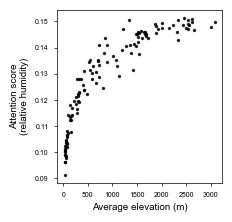

In [153]:
# Scatter plot of average elevation vs. the attention score for "Cloud area fraction".
# Spearman correlation is calculated.

fig, ax = plt.subplots(figsize=mm2inch(60, 55), gridspec_kw = {'left': 0.25, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
ax.scatter(x = [avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index],
           y = df_attention_order['Relative humidity'], 
           c = 'black', 
           alpha = 0.8, 
           s = 2)
ax.set_xlabel('Average elevation (m)')
ax.set_ylabel('Attention score\n(relative humidity)')
rho_cltelev, p_cltelev = spearmanr([avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index], 
                                   df_attention_order['Relative humidity'])
print(rho_cltelev, p_cltelev)

plot_output = os.path.join(PU.plot_path_attention, 'atthurs_elev.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Boxplot: Forest vs Non-forest

LandcoverPC3: 7.058842683694505 1.2085411999876755e-10
LandcoverPC1: 7.671543243007108 5.162794977920167e-12


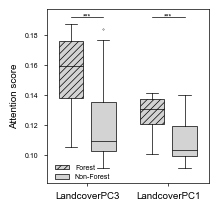

In [160]:
# Extract attention scores for forest and non-forest species for two predictors
forest_pc3 = df_attention_order['LandcoverPC3'][np.array(habitat) == 'Habitat_Forest'].dropna()
nonforest_pc3 = df_attention_order['LandcoverPC3'][np.array(habitat) != 'Habitat_Forest'].dropna()

forest_pc1 = df_attention_order['LandcoverPC1'][np.array(habitat) == 'Habitat_Forest'].dropna()
nonforest_pc1 = df_attention_order['LandcoverPC1'][np.array(habitat) != 'Habitat_Forest'].dropna()

# Run t-tests and get significance stars
t_pc3, p_pc3 = ttest_ind(forest_pc3, nonforest_pc3)
t_pc1, p_pc1 = ttest_ind(forest_pc1, nonforest_pc1)
stars_pc3 = get_significance_stars(p_pc3)
stars_pc1 = get_significance_stars(p_pc1)

print('LandcoverPC3:', t_pc3, p_pc3)
print('LandcoverPC1:', t_pc1, p_pc1)

# Prepare data lists
data_forest = [forest_pc3, forest_pc1]
data_nonforest = [nonforest_pc3, nonforest_pc1]
x_ticks_labels = ['LandcoverPC3', 'LandcoverPC1']

# Define paired positions for forest and non-forest (offset to left/right)
positions_base = np.array([0, 2])
positions_forest = positions_base - 0.4
positions_nonforest = positions_base + 0.4

# Create figure
fig, ax = plt.subplots(figsize=mm2inch(55, 55),
                       gridspec_kw={'left': 0.20, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})

# Boxplot color setup
def set_box_color(bp, hatch=None):
    for patch in bp['boxes']:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgrey')
        if hatch:
            patch.set_hatch(hatch)
    for key in ['whiskers', 'caps', 'medians']:
        for item in bp[key]:
            item.set_color('black')

# Draw forest and non-forest boxplots
bp_forest = ax.boxplot(data_forest, positions=positions_forest, sym='.', widths=0.6, patch_artist=True)
bp_nonforest = ax.boxplot(data_nonforest, positions=positions_nonforest, sym='.', widths=0.6, patch_artist=True)

set_box_color(bp_forest, hatch='/////')
set_box_color(bp_nonforest)

# Axis labels and ticks
ax.set_xticks(positions_base)
ax.set_xticklabels(x_ticks_labels, fontsize = 7)
ax.set_ylabel('Attention score')

# Set y-axis range based on all values
all_vals = np.concatenate([forest_pc3, nonforest_pc3, forest_pc1, nonforest_pc1])
ymin = np.min(all_vals) - 0.1 * (np.max(all_vals) - np.min(all_vals))
ymax = np.max(all_vals) + 0.1 * (np.max(all_vals) - np.min(all_vals))
ax.set_ylim(ymin, ymax)
ax.set_xlim(-1, 3)
ax.grid(False)

# Add significance stars above each pair of boxes
pairs_info = [
    (positions_forest[0], positions_nonforest[0], stars_pc3,
     max(np.max(forest_pc3), np.max(nonforest_pc3), np.max(forest_pc1), np.max(nonforest_pc1))),
    (positions_forest[1], positions_nonforest[1], stars_pc1,
     max(np.max(forest_pc3), np.max(nonforest_pc3), np.max(forest_pc1), np.max(nonforest_pc1))),
]

for pf, pn, star, y_pair_max in pairs_info:
    x_center = (pf + pn) / 2
    y_text = y_pair_max + 0.03 * (ymax - ymin)
    ax.text(x_center, y_text, star, ha='center', va='bottom', color='black')
    y_line = y_text + 0.001    # draw a thin horizontal line under the star
    ax.plot([pf, pn], [y_line, y_line], color='black', linewidth=0.5)

# Add legend (Forest = hatched; Non-Forest = plain)
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='lightgrey', edgecolor='black', hatch='/////', label='Forest', linewidth=0.5),
    Patch(facecolor='lightgrey', edgecolor='black', label='Non-Forest', linewidth=0.5)
]
ax.legend(handles=legend_handles, loc=(0.038,0))

# Save figure
plot_output = os.path.join(PU.plot_path_attention, 'forest_nonforest_landcoverPC1_PC3_combined.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

In [41]:
PU.coocc_counts[PU.coocc_counts.counts != 0]

,sp1,sp2,counts
0,Abroscopus_albogularis,Acanthis_flammea,3
1,Abroscopus_albogularis,Accipiter_badius,12
2,Abroscopus_albogularis,Accipiter_gentilis,130
3,Abroscopus_albogularis,Accipiter_gularis,219
4,Abroscopus_albogularis,Accipiter_nisus,182
...,...,...,...
107792,Zosterops_erythropleurus,Zosterops_meyeni,2
107793,Zosterops_erythropleurus,Zosterops_simplex,52
107794,Zosterops_japonicus,Zosterops_meyeni,23
107795,Zosterops_japonicus,Zosterops_simplex,46557


### Corelation between environmental factor value and attention score (沒用到)

In [100]:
env_value_all = {}
for i, env in enumerate(PU.env_list_detail):
    env_folder = f'./workspace/raster_data/env_aligned_timespan_avg/{PU.env_list[i]}'
    files = os.listdir(env_folder)
    env_value = []
    for file in files:
        with rasterio.open(os.path.join(env_folder, file), 'r') as f:
            img = f.read(1)
        img = img[img != -9999]
        env_value.append(img)
    env_values = np.concatenate(env_value)
    if PU.env_list[i] not in PU.DeepSDM_conf.training_conf['non_normalize_env_list']:
        env_values = (env_values - PU.env_info['info'][PU.env_list[i]]['mean'])/PU.env_info['info'][PU.env_list[i]]['sd']
    env_value_all[env] = env_values
    

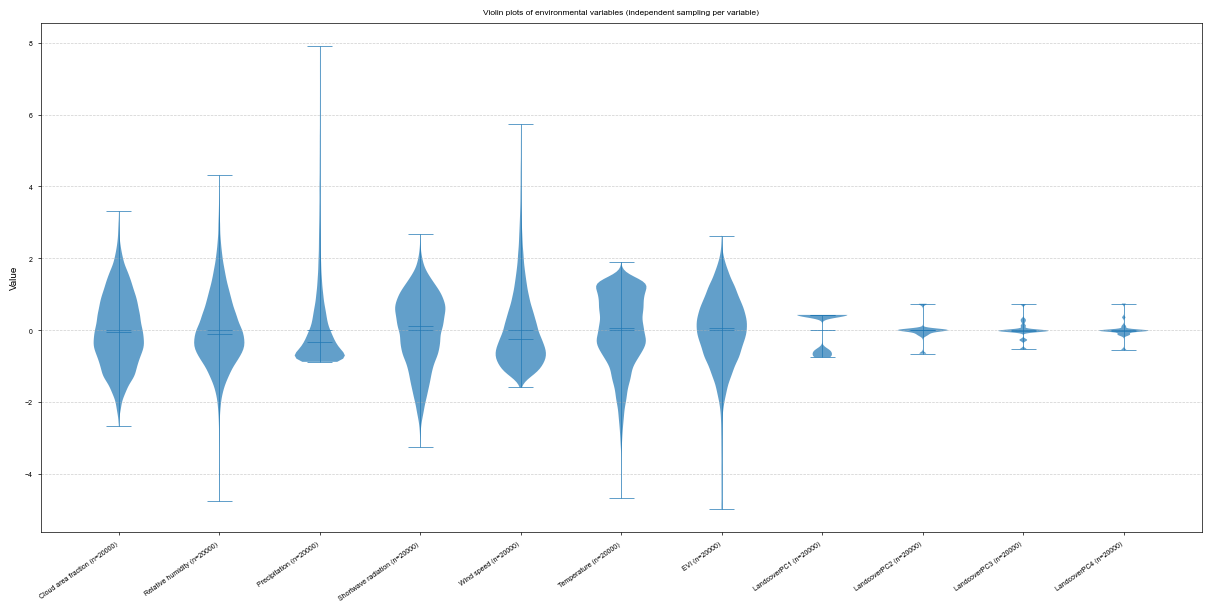

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# -------- 參數 --------
sample_size = 20000                 # 每個變數最多抽樣數量，可依記憶體調整
rng = np.random.default_rng(42)     # 固定亂數種子（可改/移除）
order = PU.env_list_detail
# 只保留實際存在的鍵；若沒有指定順序，就直接用 dict 的鍵順序
order = [k for k in order if k in env_value_all] or list(env_value_all.keys())

def clean_and_sample(arr, nmax, rng):
    a = np.asarray(arr)
    a = a[np.isfinite(a)]           # 去除 NaN/Inf
    if a.size == 0:
        return a
    n = min(nmax, a.size)
    idx_local = rng.choice(a.size, size=n, replace=False)  # 各變數各抽各的
    return a[idx_local]

# -------- 準備資料（各自獨立抽樣）--------
data, labels = [], []
for k in order:
    sampled = clean_and_sample(env_value_all[k], sample_size, rng)
    if sampled.size > 0:
        data.append(sampled)
        labels.append(f"{k} (n={sampled.size})")

# -------- 作圖（純 matplotlib）--------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

parts = ax.violinplot(
    dataset=data, 
    showmeans=True, 
    showmedians=True, 
    showextrema=True
)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_title("Violin plots of environmental variables (independent sampling per variable)")
ax.set_ylabel("Value")

# 小提琴透明度微調（不指定顏色，照預設）
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.show()


Spearman correlation between IQR and mean attention:
ρ = -0.137, p = 6.886e-01


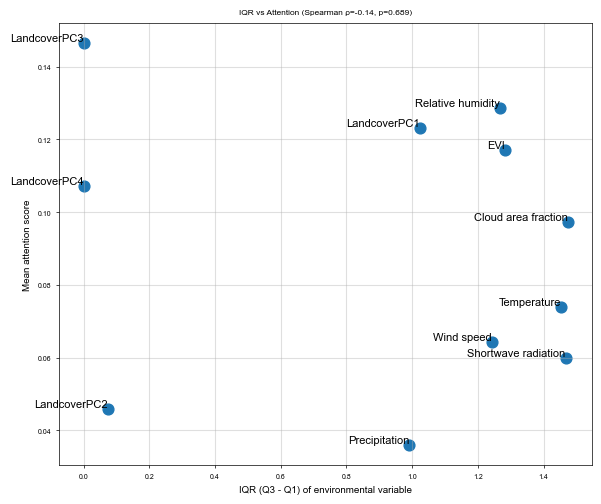

,Q1,Q3,IQR,Mean_attention,logIQR
Cloud area fraction,-0.750343,0.723099,1.473442,0.097296,0.168333
Relative humidity,-0.665872,0.601172,1.267044,0.128723,0.102792
Precipitation,-0.680690,0.310717,0.991407,0.035920,-0.003748
Shortwave radiation,-0.698884,0.767955,1.466839,0.059773,0.166382
Wind speed,-0.737138,0.505581,1.242719,0.064317,0.094373
Temperature,-0.621879,0.831016,1.452895,0.074011,0.162234
EVI,-0.594349,0.688391,1.282740,0.117059,0.108139
LandcoverPC1,-0.594043,0.429250,1.023293,0.123196,0.010000
LandcoverPC2,-0.065891,0.008600,0.074490,0.045809,-1.127899
LandcoverPC3,-0.013040,-0.013040,0.000000,0.146608,-8.000000


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# === 1. 計算每個環境因子的 IQR ===
records = []
for k, arr in env_value_all.items():
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]  # 去除 NaN / Inf
    if arr.size == 0:
        continue
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    records.append({"Variable": k, "Q1": q1, "Q3": q3, "IQR": iqr})

df_iqr = pd.DataFrame(records).set_index("Variable")

# === 2. 計算 attention score 的平均值 ===
# 假設 df_attention_order 的欄位名稱與 env_value_all 的 key 對應（例如 Precipitation, LandcoverPC1 ...）
df_attention_mean = df_attention_order.mean(axis=0).to_frame("Mean_attention")

# === 3. 合併兩者 ===
df_compare = pd.concat([df_iqr, df_attention_mean], axis=1, join="inner").dropna()
df_compare["logIQR"] = np.log10(df_compare["IQR"] + 1e-8)  # 為了看趨勢可取 log

# === 4. 計算相關係數 ===
rho, pval = spearmanr(df_compare["IQR"], df_compare["Mean_attention"])
print("Spearman correlation between IQR and mean attention:")
print(f"ρ = {rho:.3f}, p = {pval:.3e}")

# === 5. 畫圖 ===
plt.figure(figsize=(6, 5))
plt.scatter(df_compare["IQR"], df_compare["Mean_attention"], s=60)
for name, row in df_compare.iterrows():
    plt.text(row["IQR"], row["Mean_attention"], name, fontsize=8, ha="right", va="bottom")

plt.xlabel("IQR (Q3 - Q1) of environmental variable")
plt.ylabel("Mean attention score")
plt.title(f"IQR vs Attention (Spearman ρ={rho:.2f}, p={pval:.3g})")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

df_compare


### Check if nest structures are related to attention scores of RELATIVE HUMIDITY (沒用到)

In [48]:
def get_species_nest_structure(df_attention_order):
    """
    Retrieve nest-related information from the trait dataset for each species
    and map them to a final list for plotting/analysis.
    """
    taxon_df = pd.read_csv(PU.traitdataset_taxon_path, delimiter='\t')
    measurement_df = pd.read_csv(PU.traitdataset_mesurement_path, delimiter='\t')
    nest_related_df = measurement_df[
        measurement_df['measurementType'].str.contains('Neststructure', na=False, case=False)
    ]
    merged_nest_df = nest_related_df.merge(taxon_df, left_on='id', right_on='taxonID', how='left')
    merged_nest_df['measurementValue'] = merged_nest_df['measurementValue'].astype(float)
    best_nest = merged_nest_df.loc[merged_nest_df.groupby('taxonID')['measurementValue'].idxmax()]
    species_nest_df = best_nest[['scientificName', 'measurementType']].copy()

    name_to_change = {
        'Porzana fusca': 'Zapornia fusca',
        'Gallirallus striatus': 'Lewinia striata',
        'Stachyridopsis ruficeps': 'Cyanoderma ruficeps',
        'Pomatorhinus erythrocnemis': 'Erythrogenys erythrocnemis',
        'Alcippe brunnea': 'Schoeniparus brunneus',
        'Ictinaetus malayensis': 'Ictinaetus malaiensis',
        'Poecile varius': 'Sittiparus castaneoventris',
        'Parus holsti': 'Machlolophus holsti',
        'Turdus poliocephalus': 'Turdus niveiceps',
        'Garrulax poecilorhynchus': 'Pterorhinus poecilorhynchus',
        'Garrulax ruficeps': 'Pterorhinus ruficeps',
        'Glaucidium brodiei': 'Taenioptynx brodiei',
        'Tarsiger indicus': 'Tarsiger formosanus'
    }

    df_attention_sp_name = list(df_attention_order.index)
    for i, name in enumerate(df_attention_sp_name):
        if name in name_to_change:
            df_attention_sp_name[i] = name_to_change[name]
    nest = []
    for sp in df_attention_sp_name:
        if sp not in species_nest_df.scientificName.tolist():
            nest.append(None)
        else:
            nest.append(species_nest_df.measurementType[species_nest_df.scientificName == sp].values.tolist()[0])

    return nest
nest = get_species_nest_structure(df_attention_order)

In [49]:
open_value = []
closed_value = []
for i, n in enumerate(np.array(nest)):
    if n in ['Neststructure_Scrape', 'Neststructure_Platform', 'Neststructure_Cup']:
        open_value.append(df_attention_order['Relative humidity'].iloc[i])
    else:
        closed_value.append(df_attention_order['Relative humidity'].iloc[i])

In [50]:
ttest_ind(open_value, closed_value)

TtestResult(statistic=-1.2522398871858729, pvalue=0.21293799726467322, df=119.0)